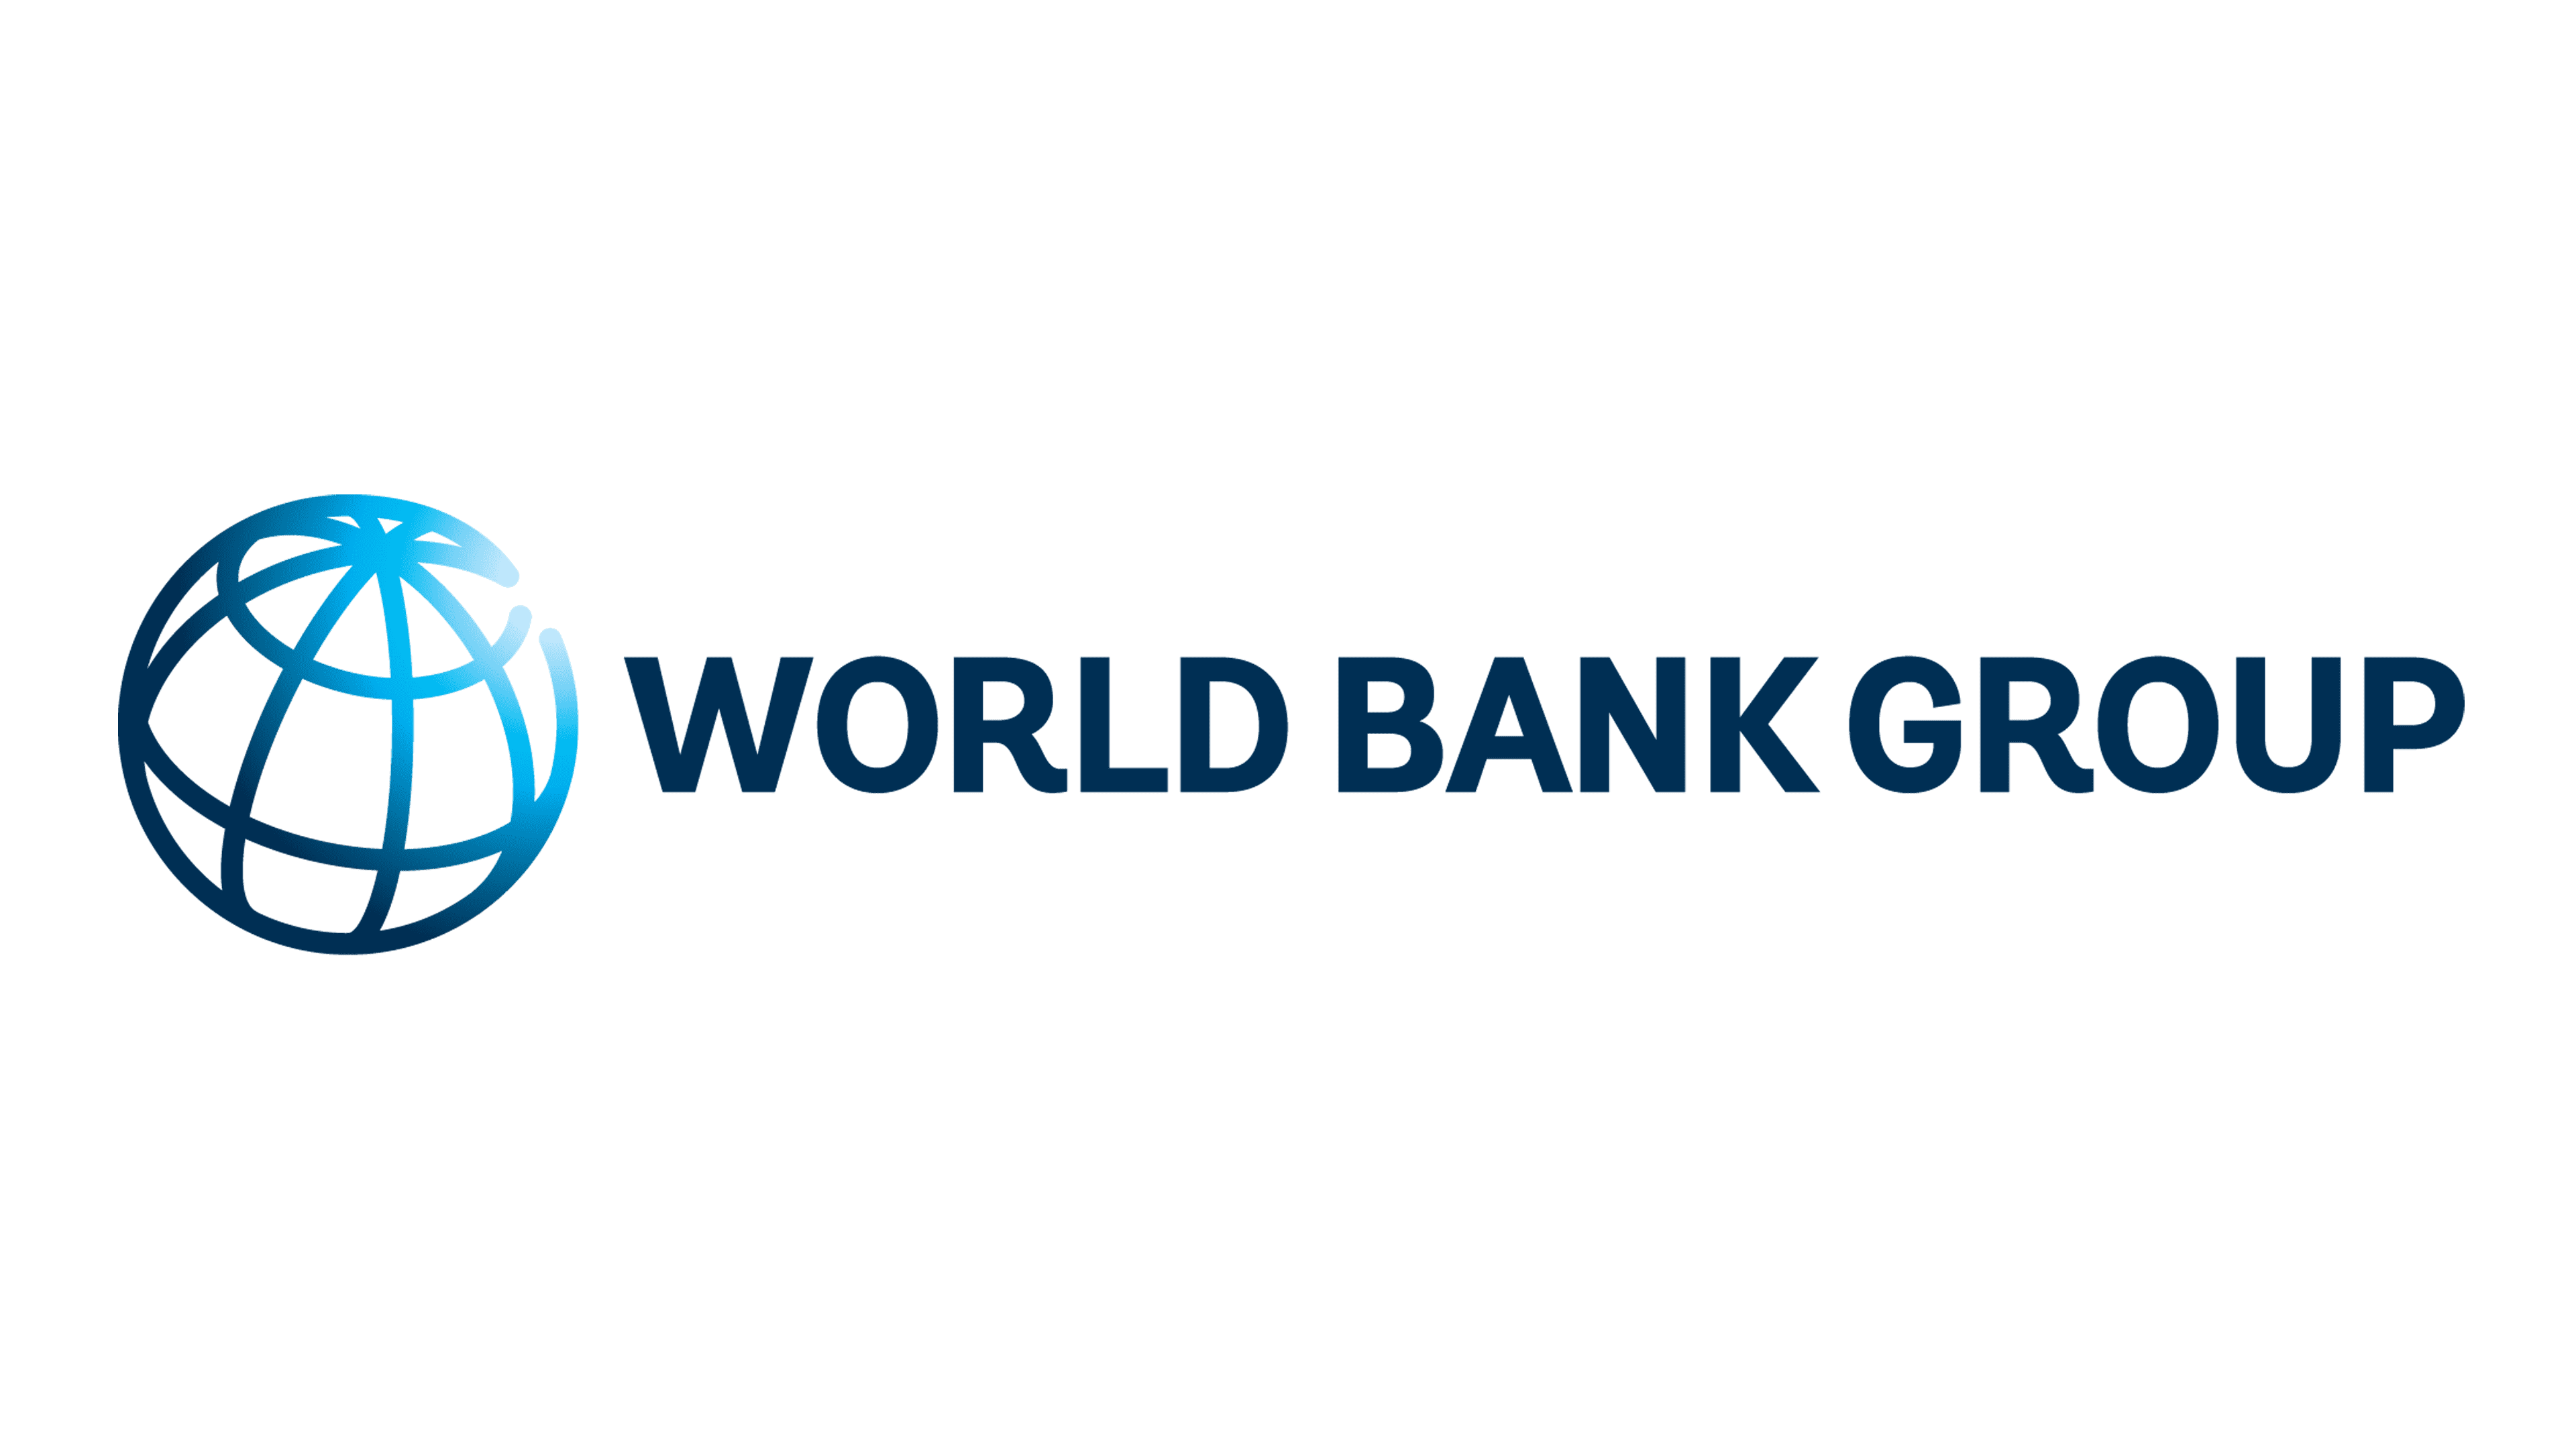

## Modelos de Regresión

En esta actividad se utilizarán indicadores macroeconómicos obtenidos desde la base de datos del Banco Mundial (World Development Indicators, WDI) con el objetivo de predecir el **PIB per cápita** de los países.

| Variable | Código WDI | Descripción |
|---|---|---|
| Inflación | `FP.CPI.TOTL.ZG` | Inflación, precios al consumidor (%) |
| Inversión | `NE.GDI.TOTL.ZS` | Formación bruta de capital |
| Exportaciones | `NE.EXP.GNFS.ZS` | Exportaciones de bienes y servicios |
| Gasto gobierno | `NE.CON.GOVT.ZS` | Consumo del gobierno|
| Desempleo | `SL.UEM.TOTL.ZS` | Desempleo (% fuerza laboral) |
| Crédito privado | `FS.AST.PRVT.GD.ZS` | Crédito al sector privado|
| PIB per cápita | `NY.GDP.PCAP.KD` | PIB per cápita (US$ constantes 2015) |

### 1. Preparación del Entorno y Descarga de Datos
La descarga de datos sera utilizando la biblioteca [wbgapi](https://https://pypi.org/project/wbgapi/)

In [5]:
!pip install wbgapi

In [6]:
# Importar bibliotecas
import wbgapi as wb #API del WB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # Separar el set de datos
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Importar métricas de rendimientos

# Importar módulo para ignorar errores
from warnings import filterwarnings
filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [7]:
# Diccionario: código WDI → nombre descriptivo
indicadores = {
    'NY.GDP.PCAP.KD':    'PIB_PerCapita',      # TARGET (Y)
    'FP.CPI.TOTL.ZG':    'Inflacion',
    'NE.GDI.TOTL.ZS':    'Inversion',
    'NE.EXP.GNFS.ZS':    'Exportaciones',
    'NE.CON.GOVT.ZS':    'Gasto_Gobierno',
    'SL.UEM.TOTL.ZS':    'Desempleo',
    'FS.AST.PRVT.GD.ZS': 'Credito_Privado'}


# Descargar datos para todos los países, periodo 2000-2022
df_raw = wb.data.DataFrame(
    list(indicadores.keys()),
    time=range(2010, 2020),
    labels=True,
    columns='series'
)

# Renombrar columnas
df_raw.rename(columns=indicadores, inplace=True)

# Resetear indice
df_raw = df_raw.reset_index()


usando `head()` visualizamos los primeros registros del data

In [8]:
# Primeros registros
df_raw.head(2)

,economy,time,Country,Time,Inflacion,Credito_Privado,Gasto_Gobierno,Exportaciones,Inversion,PIB_PerCapita,Desempleo
0,ZWE,YR2019,Zimbabwe,2019,255.3050,3.4280,4.8034,18.0339,6.5858,1357.5309,7.3730
1,ZWE,YR2018,Zimbabwe,2018,10.6189,5.8303,10.3742,26.1641,14.1484,1472.1460,6.7880


In [39]:
sorted(df_raw['Country'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas, The',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei Darussalam',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cabo Verde',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo, Dem. Rep.',
 'Congo, Rep.',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt, Arab Rep.',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Faroe Islands',
 'Fiji',
 'Finland',
 'France',
 'French Polynesia',
 'Gab

In [9]:
#Cargar tablas de la pagina web
url_iban = "https://www.iban.com/country-codes"
iban_tables = pd.read_html(url_iban)
df_iban = iban_tables[0]
df_iban = df_iban[['Country','Alpha-3 code']]
df_iban.columns = ['country','economy']

Para seleccionar solamente paises utilizaremos la informacion provista en el sitio web [IBAN](https://www.iban.com/)



In [10]:
df_raw = pd.merge(df_raw,df_iban['economy'], how = 'inner', on = 'economy')

In [11]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   economy          2150 non-null   object 
 1   time             2150 non-null   object 
 2   Country          2150 non-null   object 
 3   Time             2150 non-null   object 
 4   Inflacion        1869 non-null   float64
 5   Credito_Privado  1722 non-null   float64
 6   Gasto_Gobierno   1746 non-null   float64
 7   Exportaciones    1813 non-null   float64
 8   Inversion        1735 non-null   float64
 9   PIB_PerCapita    2076 non-null   float64
 10  Desempleo        1860 non-null   float64
dtypes: float64(7), object(4)
memory usage: 184.9+ KB


In [13]:
df = df_raw.dropna().reset_index(drop = True)

se utiliza la funcion `headmap()` para evaluar la correlacion de las variables

<Axes: >

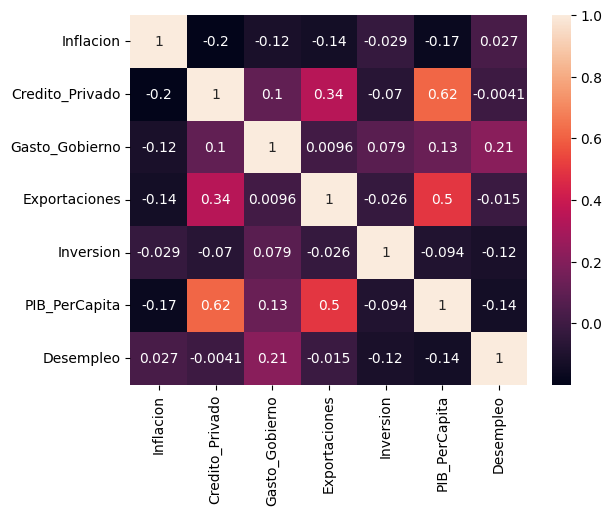

In [14]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True)

se elimina variable de alta correlacion *Credito_Privado* para evitar problemas de multicolinealidad.

In [15]:
df = df.drop(columns = 'Credito_Privado')

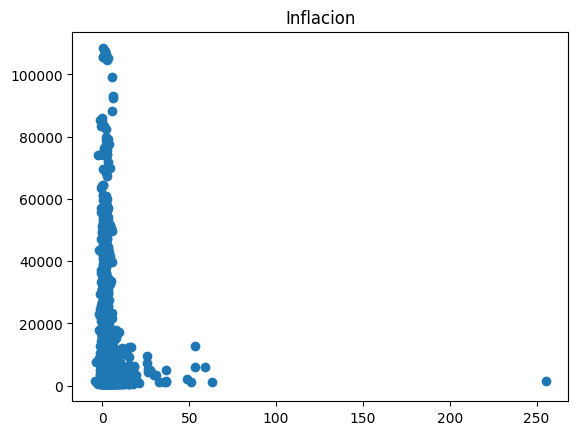

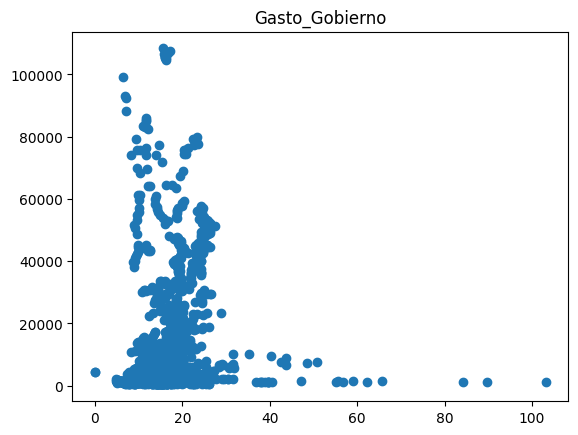

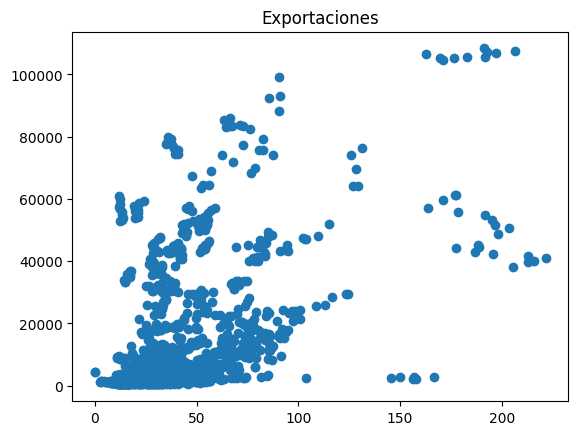

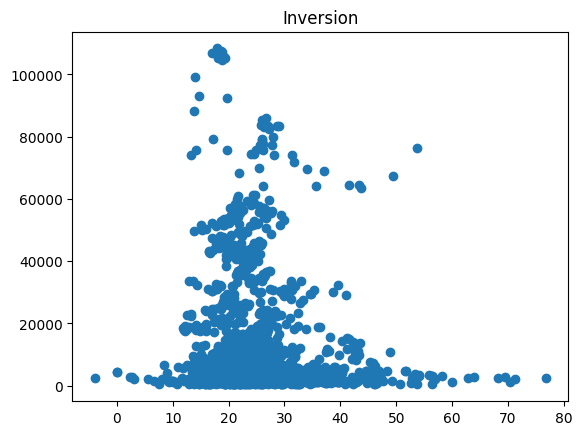

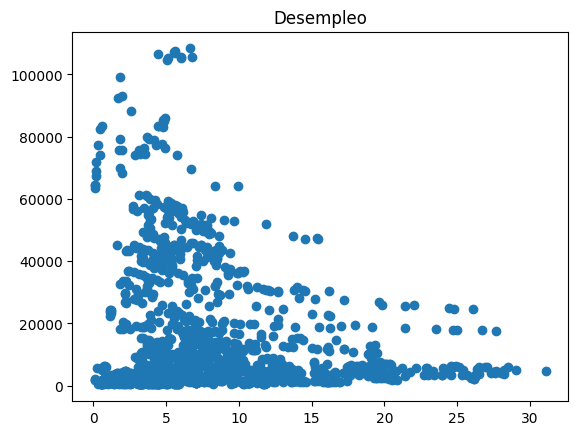

In [16]:
numeric_col = df.select_dtypes('number').columns
numeric_col = numeric_col.drop('PIB_PerCapita')

for col in numeric_col:

    plt.scatter(y = df['PIB_PerCapita'], x = df[col])
    plt.title(col)
    plt.show()

### 3. Preparación de Features y Target

In [17]:
#@title Crear función para visualizar métricas
def fn_metricas_info(modelo, y_verdadero, y_calculado):
    metrics = {
        'MAE': mean_absolute_error(y_verdadero, y_calculado),
        'MSE': mean_squared_error(y_verdadero, y_calculado),
        'RMSE': np.sqrt(mean_squared_error(y_verdadero, y_calculado)),
        'R2': r2_score(y_verdadero, y_calculado)
    }
    return pd.DataFrame(metrics, index=[modelo])

In [18]:
metricas = pd.DataFrame()

In [19]:
df_numeric = df.select_dtypes('number')
y = df_numeric['PIB_PerCapita']
X = df_numeric.drop(columns='PIB_PerCapita')

# Particionar data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.25, random_state=42)

**Regresión Lineal**

In [20]:
from sklearn.linear_model import LinearRegression # Regresión Lineal

rl = LinearRegression(fit_intercept = True)

# Entrenar set de prueba
rl.fit(X_train, y_train)

LinearRegression()

In [21]:
# Testear
y_train_pred = rl.predict(X_train)
y_test_pred = rl.predict(X_test)


display(fn_metricas_info('Regresión Lineal - train', y_train, y_train_pred))
display(fn_metricas_info('Regresión Lineal - test', y_test, y_test_pred))

# Guardar resultados
metricas = fn_metricas_info('Regresión Lineal - test', y_test, y_test_pred)

,MAE,MSE,RMSE,R2
Regresión Lineal - train,12032.8238,281490711.1508,16777.6849,0.2687


,MAE,MSE,RMSE,R2
Regresión Lineal - test,10886.2750,259047250.6884,16094.9449,0.3923


In [22]:
coeficientes = rl.coef_
variables = X.columns
pd.DataFrame({'variables': variables, 'coeficientes reg lineal': coeficientes})

,variables,coeficientes reg lineal
0,Inflacion,-168.2400
1,Gasto_Gobierno,498.3425
2,Exportaciones,269.4812
3,Inversion,-251.4979
4,Desempleo,-622.3646


**Regresión Ridge**

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

# Particiones para validación cruzada
particiones = KFold(n_splits=10, shuffle=True, random_state=42)

# Valores de alpha solicitados
param_grid = {'alpha': [0.1,1,10,20,30]}

# Modelo Ridge
ridge = Ridge()

# Búsqueda de hiperparámetros
grid_search_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=particiones,
    scoring='neg_mean_squared_error'
)

# Entrenamiento
grid_search_ridge.fit(X_train_scaled, y_train)

# Mejor modelo
best_ridge = grid_search_ridge.best_estimator_

print(f"El mejor valor de alpha es: {grid_search_ridge.best_params_['alpha']}")

# Predicciones
y_train_pred = best_ridge.predict(X_train_scaled)
y_test_pred = best_ridge.predict(X_test_scaled)

# Métricas
display(fn_metricas_info("Modelo Ridge - Train", y_train, y_train_pred))
display(fn_metricas_info("Modelo Ridge - Test", y_test, y_test_pred))

El mejor valor de alpha es: 30


,MAE,MSE,RMSE,R2
Modelo Ridge - Train,12021.7736,281570133.2639,16780.0516,0.2684


,MAE,MSE,RMSE,R2
Modelo Ridge - Test,10900.2396,260597280.1719,16143.0257,0.3887


In [25]:
coeficientes = best_ridge.coef_
variables = X.columns
pd.DataFrame({'variables': variables, 'coeficientes ridge': coeficientes})

,variables,coeficientes ridge
0,Inflacion,-1609.2581
1,Gasto_Gobierno,3515.2565
2,Exportaciones,8229.8531
3,Inversion,-2070.9178
4,Desempleo,-3535.3417


In [26]:
metricas = pd.concat([metricas, fn_metricas_info("Modelo Ridge - Test", y_test, y_test_pred)], axis = 0)

In [27]:
metricas

,MAE,MSE,RMSE,R2
Regresión Lineal - test,10886.2750,259047250.6884,16094.9449,0.3923
Modelo Ridge - Test,10900.2396,260597280.1719,16143.0257,0.3887


**Regresión Lasso**

In [28]:
from sklearn.linear_model import Lasso

# Particiones para validación cruzada
particiones = KFold(n_splits=10, shuffle=True, random_state=42)

# Valores de alpha solicitados
param_grid = {'alpha': [0.1,1,10,20,30]}

# Modelo Ridge
lasso = Lasso()

# Búsqueda de hiperparámetros
grid_search_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=particiones,
    scoring='neg_mean_squared_error'
)

# Entrenamiento
grid_search_lasso.fit(X_train_scaled, y_train)

# Mejor modelo
best_lasso= grid_search_lasso.best_estimator_

print(f"El mejor valor de alpha es: {grid_search_lasso.best_params_['alpha']}")

# Predicciones
y_train_pred = best_lasso.predict(X_train_scaled)
y_test_pred = best_lasso.predict(X_test_scaled)

# Métricas
display(fn_metricas_info("Modelo Lasso - Train", y_train, y_train_pred))
display(fn_metricas_info("Modelo Lasso - Test", y_test, y_test_pred))

El mejor valor de alpha es: 30


,MAE,MSE,RMSE,R2
Modelo Lasso - Train,12029.2472,281495615.3734,16777.8311,0.2686


,MAE,MSE,RMSE,R2
Modelo Lasso - Test,10884.9621,259210316.1436,16100.0098,0.3919


In [29]:
metricas = pd.concat([metricas, fn_metricas_info("Modelo Lasso - Test", y_test, y_test_pred)], axis = 0)
metricas

,MAE,MSE,RMSE,R2
Regresión Lineal - test,10886.2750,259047250.6884,16094.9449,0.3923
Modelo Ridge - Test,10900.2396,260597280.1719,16143.0257,0.3887
Modelo Lasso - Test,10884.9621,259210316.1436,16100.0098,0.3919


In [30]:
coeficientes = best_lasso.coef_
variables = X.columns
pd.DataFrame({'variables': variables, 'coeficientes': coeficientes})

,variables,coeficientes
0,Inflacion,-1587.9792
1,Gasto_Gobierno,3602.7352
2,Exportaciones,8427.3196
3,Inversion,-2107.3198
4,Desempleo,-3624.1586


**Nota Optativa: Comparación de coeficientes en escala original**

*Ridge y Lasso se entrenaron con datos normalizados, por lo que sus coeficientes están en términos de desviaciones estándar. Para una comparación justa con Regresión Lineal, se desnormalizan dividiendo por la desviación estándar de cada variable.*

In [31]:
# Obtener desviaciones estándar de los features normalizados
std_scaling = scaler.scale_

# Desnormalizar coeficientes de Ridge y Lasso
coef_ridge_original = best_ridge.coef_ / std_scaling
coef_lasso_original = best_lasso.coef_ / std_scaling

# Crear tabla comparativa
comparacion_coef = pd.DataFrame({
    'Variable': X.columns,
    'Regresión Lineal': rl.coef_,
    'Ridge (desnorm.)': coef_ridge_original,
    'Lasso (desnorm.)': coef_lasso_original
})

print("COMPARACIÓN DE COEFICIENTES (escala original)\n")
display(comparacion_coef)

COMPARACIÓN DE COEFICIENTES (escala original)



,Variable,Regresión Lineal,Ridge (desnorm.),Lasso (desnorm.)
0,Inflacion,-168.2400,-168.1375,-165.9142
1,Gasto_Gobierno,498.3425,481.3370,493.3153
2,Exportaciones,269.4812,262.3485,268.6433
3,Inversion,-251.4979,-242.8629,-247.1319
4,Desempleo,-622.3646,-600.3236,-615.4052


**INTERPRETACIÓN:**

- Ridge y Lasso mantienen direcciones (signos) similares a Regresión Lineal
- Ridge/Lasso amplifican ligeramente la magnitud de los coeficientes
- Exportaciones es el predictor MÁS FUERTE (coef. > 310)
- Desempleo tiene el impacto NEGATIVO más fuerte (coef. < -600)

**Árbol de decisión**

In [32]:
# Biblioteca
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV


In [33]:
# Copair set de datos
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()

# Instanciar modelo
tree = DecisionTreeRegressor(random_state=42)

# Grilla con hiperparámetros
param_grid = {
    'max_depth': [3,5,7],
    'min_samples_split': [15,20],
    'min_samples_leaf': [15,20],
    #'max_features': [None, 'sqrt', 'log2']
}

# Ejecutar CV
gs_tree = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    cv=10,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar modelo
gs_tree.fit(X_train_tree, y_train)

print(f"Mejores hiperparámetros: {gs_tree.best_params_}")
print("Mejor MAE (CV):", abs(gs_tree.best_score_))

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Mejores hiperparámetros: {'max_depth': 7, 'min_samples_leaf': 20, 'min_samples_split': 15}
Mejor MAE (CV): 220166445.0874971


In [34]:
# Entrenar mejor modelo
best_tree = gs_tree.best_estimator_

best_tree.fit(X_train_tree, y_train)

# Predicciones
y_train_pred = best_tree.predict(X_train_tree)
y_test_pred = best_tree.predict(X_test_tree)

# Aplicar funición de métricas
display(fn_metricas_info("Árbol Decisión - Train", y_train, y_train_pred))
display(fn_metricas_info("Árbol Decisión- Test", y_test, y_test_pred))


,MAE,MSE,RMSE,R2
Árbol Decisión - Train,7336.8785,159145170.9614,12615.2753,0.5865


,MAE,MSE,RMSE,R2
Árbol Decisión- Test,8160.1055,202049139.2319,14214.3990,0.5260


In [35]:
metricas = pd.concat([metricas, fn_metricas_info("Árbol Decisión- Test", y_test, y_test_pred)], axis = 0)
metricas

,MAE,MSE,RMSE,R2
Regresión Lineal - test,10886.2750,259047250.6884,16094.9449,0.3923
Modelo Ridge - Test,10900.2396,260597280.1719,16143.0257,0.3887
Modelo Lasso - Test,10884.9621,259210316.1436,16100.0098,0.3919
Árbol Decisión- Test,8160.1055,202049139.2319,14214.3990,0.5260


En función de las métricas evaluadas, el Árbol de Decisión es el que presenta la mejor capacidad predictiva. La relación entre las variables macroeconómicas y el PIB per cápita parece tener fuertes componentes no lineales que la regresión múltiple no logra capturar, por lo que un modelo basado en particiones jerárquicas como el árbol se adapta de mucha mejor manera a la naturaleza de los datos.

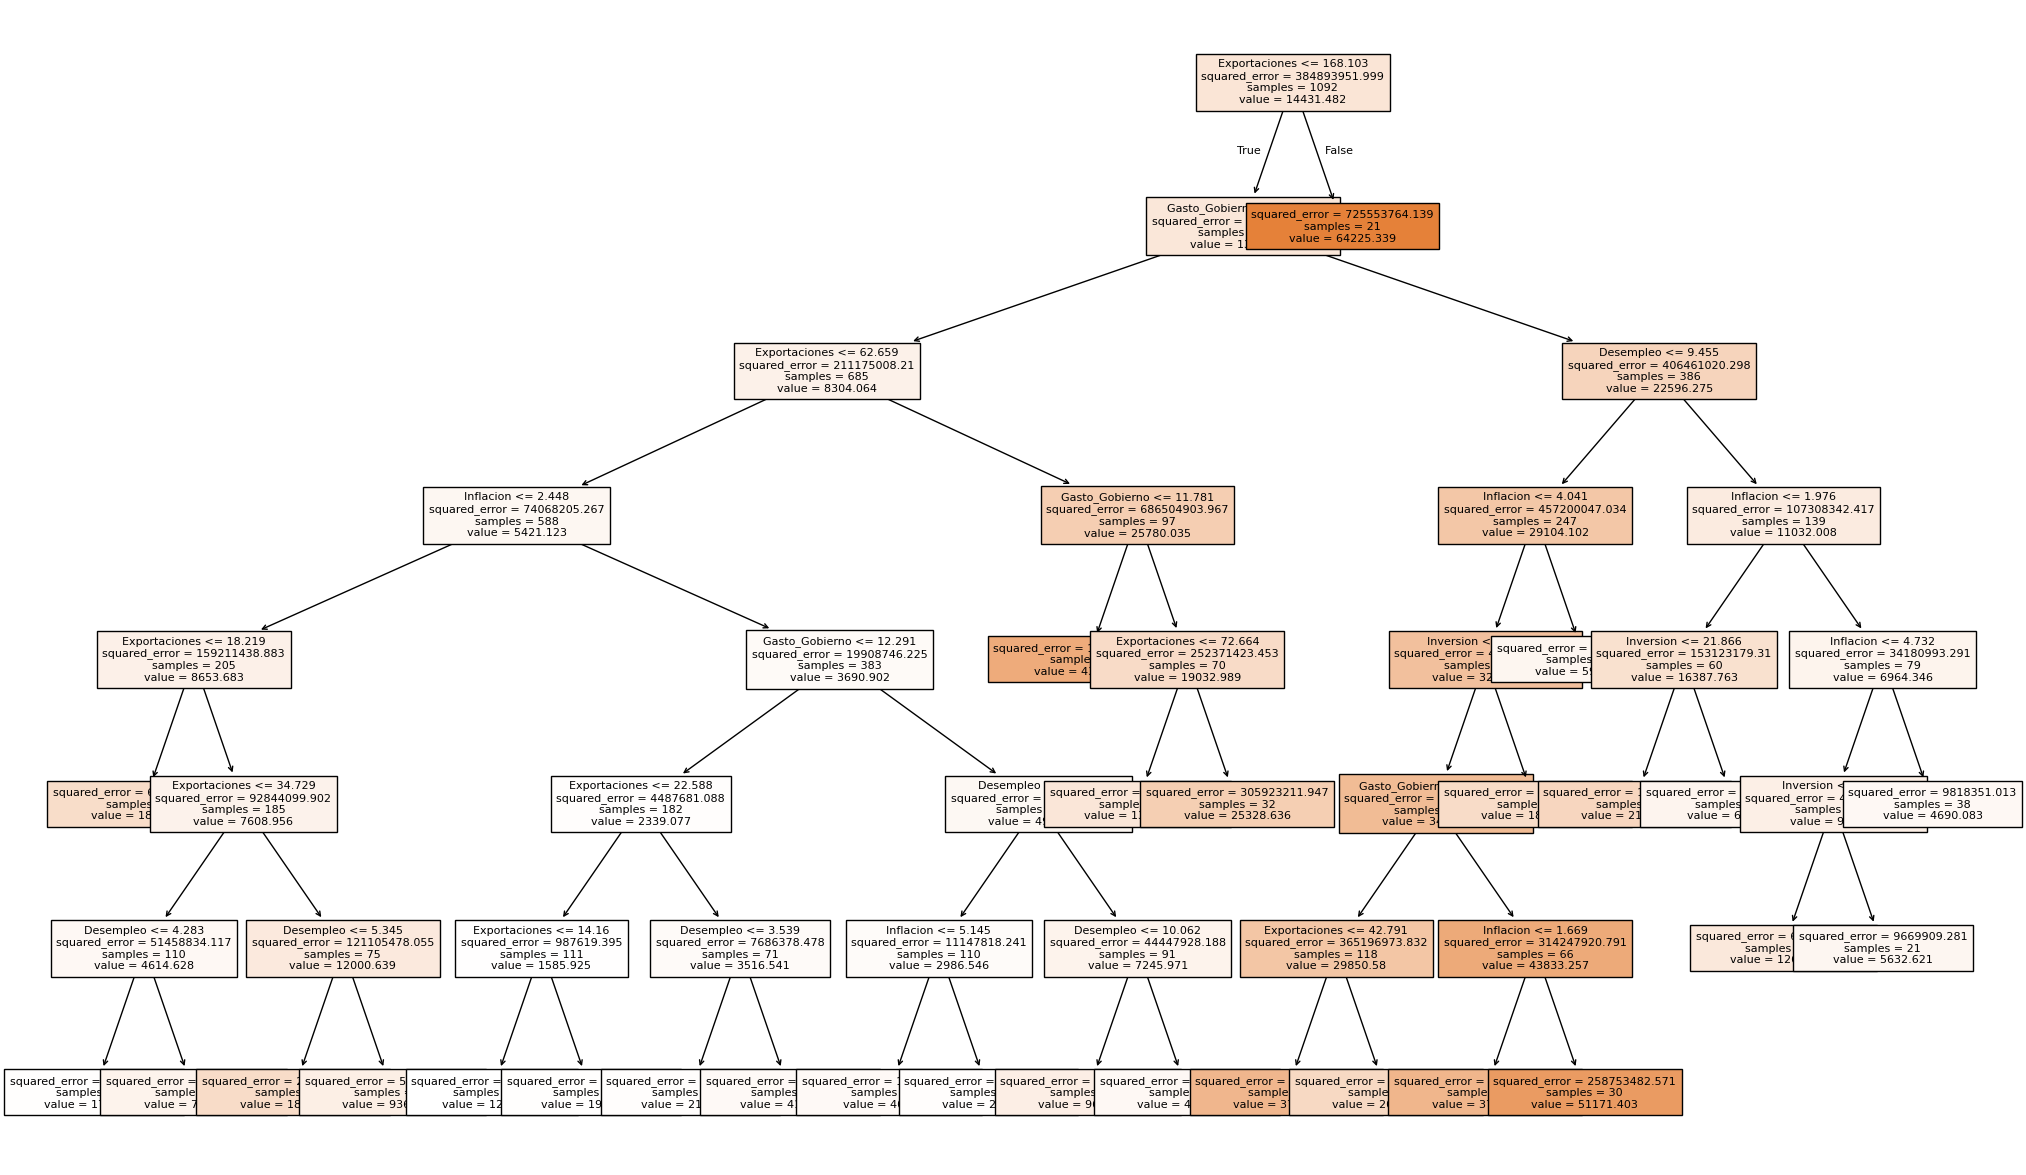

In [36]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25,15))
plot_tree(best_tree, filled=True, max_depth=gs_tree.best_params_['max_depth'], fontsize=8, feature_names=best_tree.feature_names_in_)
plt.show()